## Для таблицы

In [10]:
import math

def f(x):
    return math.log(2*x) - 5/(x**2)

print("x\t\tf(x)")
print("-" * 30)
x = 0.5
while x <= 5.5:
    print(f"{x:.7f}\t{f(x):.7f}")
    x += 0.5


x		f(x)
------------------------------
0.5000000	-20.0000000
1.0000000	-4.3068528
1.5000000	-1.1236099
2.0000000	0.1362944
2.5000000	0.8094379
3.0000000	1.2362039
3.5000000	1.5377469
4.0000000	1.7669415
4.5000000	1.9503110
5.0000000	2.1025851
5.5000000	2.2326060


## График

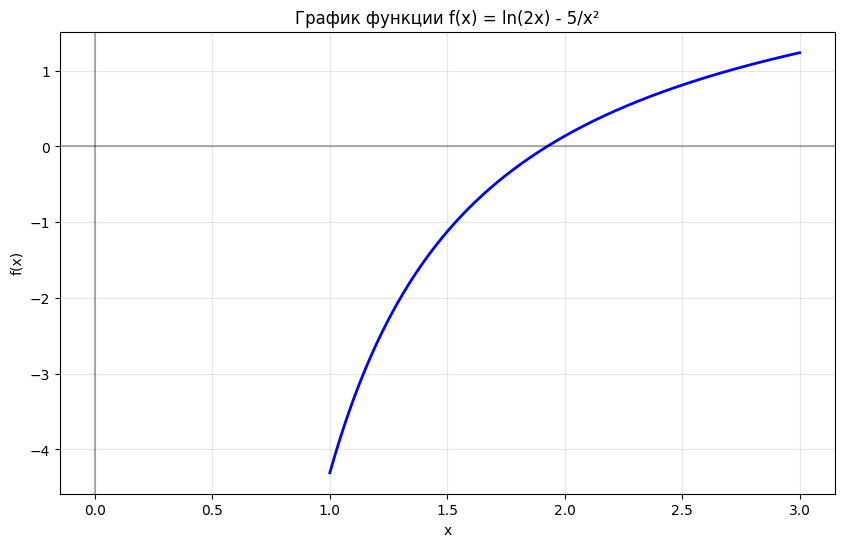

In [12]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return np.log(2*x) - 5/(x**2)

x = np.linspace(1, 3, 400)
y = f(x)

plt.figure(figsize=(10, 6))
plt.plot(x, y, 'b-', linewidth=2)
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)
plt.grid(True, alpha=0.3)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('График функции f(x) = ln(2x) - 5/x²')
plt.show()


## Все методы

In [41]:
import math

# Исходная функция и её производные
def f(x):
    """f(x) = ln(2x) - 5/x²"""
    return math.log(2*x) - 5/(x**2)

def df(x):
    """f'(x) = 1/x + 10/x³"""
    return 1/x + 10/(x**3)

def d2f(x):
    """f''(x) = -1/x² - 30/x⁴"""
    return -1/(x**2) - 30/(x**4)

eps = 1e-7  # Требуемая точность

def print_table_header():
    """Заголовок таблицы"""
    print("-" * 40)
    print(" n       x_n      ")
    print("-" * 40)

# 1. Метод Ньютона (метод касательных)
def newton_method(x0):
    print("\n1. МЕТОД НЬЮТОНА (метод касательных)")
    print_table_header()
    x_k = x0
    k = 0
    print(f"{k:>2}  {x_k:.8f}")
    while True:
        k += 1
        x_next = x_k - f(x_k) / df(x_k)
        print(f"{k:>2}  {x_next:.8f}")
        if abs(x_next - x_k) < eps:
            break
        x_k = x_next
    print(f"\nКорень: x = {x_next:.8f}")
    print(f"Количество итераций: {k}")
    return x_next, k

# 2. Метод хорд
def chord_method(a, b):
    print("\n2. МЕТОД ХОРД")
    print_table_header()

    # Проверяем условие f(a)*f(b) < 0
    if f(a) * f(b) >= 0:
        print("На интервале нет корня или несколько корней")
        return None, 0

    # Выбираем неподвижный конец
    if f(a) * d2f(a) > 0:
        fixed = a
        x_k = b
    else:
        fixed = b
        x_k = a

    k = 0
    print(f"{k:>2}  {x_k:.8f}")

    while True:
        k += 1
        if f(fixed) - f(x_k) == 0:
            break
        x_next = x_k - f(x_k) * (fixed - x_k) / (f(fixed) - f(x_k))
        print(f"{k:>2}  {x_next:.8f}")
        if abs(x_next - x_k) < eps:
            break
        x_k = x_next

    print(f"\nКорень: x = {x_next:.8f}")
    print(f"Количество итераций: {k}")
    return x_next, k

# 3. Метод секущих
def secant_method(x0, x1):
    print("\n3. МЕТОД СЕКУЩИХ")
    print_table_header()

    k = 0
    print(f"{k:>2}  {x0:.8f}")
    k = 1
    print(f"{k:>2}  {x1:.8f}")

    x_prev, x_curr = x0, x1

    while True:
        k += 1
        denominator = f(x_curr) - f(x_prev)
        if abs(denominator) < 1e-12:
            break
        x_next = x_curr - f(x_curr) * (x_curr - x_prev) / denominator
        print(f"{k:>2}  {x_next:.8f}")
        if abs(x_next - x_curr) < eps:
            break
        x_prev, x_curr = x_curr, x_next

    print(f"\nКорень: x = {x_next:.8f}")
    print(f"Количество итераций: {k}")
    return x_next, k

# 4. Конечноразностный метод Ньютона
def finite_difference_newton(x0, h=0.01):
    print("\n4. КОНЕЧНОРАЗНОСТНЫЙ МЕТОД НЬЮТОНА")
    print_table_header()

    x_k = x0
    k = 0
    print(f"{k:>2}  {x_k:.8f}")

    while True:
        k += 1
        denominator = f(x_k + h) - f(x_k)
        if abs(denominator) < 1e-12:
            break
        x_next = x_k - h * f(x_k) / denominator
        print(f"{k:>2}  {x_next:.8f}")
        if abs(x_next - x_k) < eps:
            break
        x_k = x_next

    print(f"\nКорень: x = {x_next:.8f}")
    print(f"Количество итераций: {k}")
    return x_next, k

# 5. Метод Стеффенсена
def steffensen_method(x0):
    print("\n5. МЕТОД СТЕФФЕНСЕНА")
    print_table_header()

    x_k = x0
    k = 0
    print(f"{k:>2}  {x_k:.8f}")

    while True:
        k += 1
        fx = f(x_k)
        fx_plus = f(x_k + fx)
        denominator = fx_plus - fx
        if abs(denominator) < 1e-12:
            break
        x_next = x_k - fx**2 / denominator
        print(f"{k:>2}  {x_next:.8f}")
        if abs(x_next - x_k) < eps:
            break
        x_k = x_next

    print(f"\nКорень: x = {x_next:.8f}")
    print(f"Количество итераций: {k}")
    return x_next, k

# 6. Метод простых итераций
def simple_iteration_method(x0, tau=0.2):
    print("\n6. МЕТОД ПРОСТЫХ ИТЕРАЦИЙ")
    print_table_header()

    x_k = x0
    k = 0
    print(f"{k:>2}  {x_k:.8f}")

    while True:
        k += 1
        x_next = x_k - tau * f(x_k)
        print(f"{k:>2}  {x_next:.8f}")
        if abs(x_next - x_k) < eps:
            break
        x_k = x_next

    print(f"\nКорень: x = {x_next:.8f}")
    print(f"Количество итераций: {k}")
    print(f"Параметр τ = {tau}")
    return x_next, k

# Основная программа
def main():
    print("=" * 60)
    print("РЕШЕНИЕ УРАВНЕНИЯ: f(x) = ln(2x) - 5/x² = 0")
    print("=" * 60)

    # Выбранный интервал [a, b]
    a, b = 1.5, 2.0
    print(f"\nВыбранный интервал: [{a}, {b}]")
    print(f"f({a}) = {f(a):.7f}")
    print(f"f({b}) = {f(b):.7f}")
    print(f"f({a}) * f({b}) = {f(a)*f(b):.7f} < 0")
    print("Условие существования корня выполнено!")

    # Таблица результатов
    results = []

    # 1. Метод Ньютона
    x0_newton = 1.5  # Начальное приближение
    root_newton, iter_newton = newton_method(x0_newton)
    results.append(("Метод Ньютона", root_newton, iter_newton))

    # 2. Метод хорд
    root_chord, iter_chord = chord_method(a, b)
    results.append(("Метод хорд", root_chord, iter_chord))

    # 3. Метод секущих
    root_secant, iter_secant = secant_method(a, b)
    results.append(("Метод секущих", root_secant, iter_secant))

    # 4. Конечноразностный метод Ньютона
    root_fd_newton, iter_fd_newton = finite_difference_newton(1.5)
    results.append(("Конечноразностный Ньютона", root_fd_newton, iter_fd_newton))

    # 5. Метод Стеффенсена
    root_steff, iter_steff = steffensen_method(1.5)
    results.append(("Метод Стеффенсена", root_steff, iter_steff))

    # 6. Метод простых итераций
    root_iter, iter_iter = simple_iteration_method(1.5, tau=0.3)
    results.append(("Метод простых итераций", root_iter, iter_iter))

    # Итоговая таблица
    print("\n" + "=" * 80)
    print("ИТОГОВАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
    print("=" * 80)
    print(f"{'Метод решения':^30} | {'Интервал':^15} | {'Решение':^15} | {'Итерации':^10}")
    print("-" * 80)

    for method_name, root, iters in results:
        print(f"{method_name:30} | [{a:.1f}, {b:.1f}] | {root:.8f} | {iters:^10}")

    print("=" * 80)

if __name__ == "__main__":
    main()


РЕШЕНИЕ УРАВНЕНИЯ: f(x) = ln(2x) - 5/x² = 0

Выбранный интервал: [1.5, 2.0]
f(1.5) = -1.1236099
f(2.0) = 0.1362944
f(1.5) * f(2.0) = -0.1531417 < 0
Условие существования корня выполнено!

1. МЕТОД НЬЮТОНА (метод касательных)
----------------------------------------
 n       x_n      
----------------------------------------
 0  1.50000000
 1  1.80956600
 2  1.91701081
 3  1.92559128
 4  1.92563882
 5  1.92563882

Корень: x = 1.92563882
Количество итераций: 5

2. МЕТОД ХОРД
----------------------------------------
 n       x_n      
----------------------------------------
 0  2.00000000
 1  1.94591083
 2  1.93116748
 3  1.92714677
 4  1.92605013
 5  1.92575101
 6  1.92566942
 7  1.92564717
 8  1.92564110
 9  1.92563944
10  1.92563899
11  1.92563887
12  1.92563884

Корень: x = 1.92563884
Количество итераций: 12

3. МЕТОД СЕКУЩИХ
----------------------------------------
 n       x_n      
----------------------------------------
 0  1.50000000
 1  2.00000000
 2  1.94591083
 3  1.92467788